# Missingness Analysis — analytics_dataset

**Purpose:** Explore missing data patterns in the training split of `analytics_dataset`, classify each column's missingness mechanism (MCAR / MAR / MNAR), and propose a per-column imputation policy.

**Data source:** `trim-icon-498815-a0.readmission.analytics_dataset` filtered to `split_name = 'train'`.

In [1]:
# --- 1. Imports & BigQuery client setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.cloud import bigquery

# Plot defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (14, 8),
    "font.size": 11,
})
sns.set_style("whitegrid")

PROJECT = "trim-icon-498815-a0"
DATASET = "readmission"
TABLE   = "analytics_dataset"

client = bigquery.Client(project=PROJECT)

print("✓ BigQuery client initialized")

✓ BigQuery client initialized


In [2]:
# --- 2. Query the training split ---
QUERY = f"""
SELECT *
FROM `{PROJECT}.{DATASET}.{TABLE}`
WHERE split_name = 'train'
"""

df = client.query(QUERY).to_dataframe()

# Memory-efficient dtypes
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].astype("category")

print(f"Rows: {len(df):,}  |  Columns: {len(df.columns)}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Rows: 247,687  |  Columns: 46
Memory: 69.6 MB


In [3]:
# --- 3. Quick dataset overview ---
print("=== Column inventory ===\n")
overview = pd.DataFrame({
    "dtype": df.dtypes,
    "unique": df.nunique(),
    "sample": df.iloc[0].values,
})
display(overview)

print(f"\n=== Label prevalence ===")
print(f"readmission_30d = 1:  {df['readmission_30d'].mean():.1%}")
print(f"readmission_30d = 0:  {1 - df['readmission_30d'].mean():.1%}")

# Identify feature families from column name prefixes
FAMILIES = {
    "split":     ["subject_id", "hadm_id", "admittime", "dischtime", "split_bucket", "split_name"],
    "target":    ["readmission_30d"],
    "demographics": ["age", "gender", "marital_status", "language", "race",
                     "admission_type", "insurance", "discharge_location"],
    "utilization":  ["prior_admission_count", "prior_inpatient_days", "recent_ed_visits", "index_los_days"],
    "codes":        ["diagnosis_count", "procedure_count", "has_procedure"],
    "medications":  ["medication_count", "medication_order_count", "on_anticoagulant", "on_insulin"],
    "labs":         [c for c in df.columns if any(c.startswith(p) for p in
                      ["rbc_", "rdw_", "glucose_", "monocytes_"])],
}

# Print family sizes
for fam, cols in FAMILIES.items():
    present = [c for c in cols if c in df.columns]
    if present:
        print(f"  {fam:15s}: {len(present):2d} columns  ({', '.join(present[:4])}{'...' if len(present) > 4 else ''})")

=== Column inventory ===



,dtype,unique,sample
subject_id,Int64,115468,11480592
hadm_id,Int64,247687,22371778
admittime,datetime64[us],246812,2140-05-13 11:32:00
dischtime,datetime64[us],243265,2140-05-14 18:27:00
split_bucket,Int64,70,41
split_name,category,1,train
age,Int64,73,34
gender,category,2,M
marital_status,category,4,SINGLE
language,category,25,English



=== Label prevalence ===
readmission_30d = 1:  20.9%
readmission_30d = 0:  79.1%
  split          :  6 columns  (subject_id, hadm_id, admittime, dischtime...)
  target         :  1 columns  (readmission_30d)
  demographics   :  8 columns  (age, gender, marital_status, language...)
  utilization    :  4 columns  (prior_admission_count, prior_inpatient_days, recent_ed_visits, index_los_days)
  codes          :  3 columns  (diagnosis_count, procedure_count, has_procedure)
  medications    :  4 columns  (medication_count, medication_order_count, on_anticoagulant, on_insulin)
  labs           : 20 columns  (rbc_last, rbc_max, rbc_min, rbc_delta...)


In [4]:
# --- 4. Per-column missingness rates ---
missing = pd.DataFrame({
    "column":     df.columns,
    "null_count": df.isnull().sum().values,
    "null_pct":   (df.isnull().mean() * 100).values,
})

# Exclude identity/split columns from feature analysis
FEATURE_COLS = [c for c in df.columns if c not in ("subject_id", "hadm_id", "admittime", "dischtime")]
missing_feat = missing[missing["column"].isin(FEATURE_COLS)].copy()

# Assign family label
def family_of(col):
    for fam, cols in FAMILIES.items():
        if col in cols:
            return fam
    return "other"

missing_feat["family"] = missing_feat["column"].apply(family_of)
missing_feat = missing_feat.sort_values("null_pct", ascending=False)

# Print table
print(f"{'Column':<35s} {'Family':<15s} {'Null %':>8s}  {'Null Count':>10s}")
print("-" * 72)
for _, r in missing_feat.iterrows():
    if r["null_pct"] > 0:
        print(f"{r['column']:<35s} {r['family']:<15s} {r['null_pct']:7.2f}%  {r['null_count']:>10,}")
    else:
        print(f"{r['column']:<35s} {r['family']:<15s}    0.00%  {'—':>10}")

# Summary by family
family_summary = missing_feat.groupby("family").agg(
    columns=("column", "count"),
    null_columns=("null_pct", lambda x: (x > 0).sum()),
    mean_null_pct=("null_pct", "mean"),
    max_null_pct=("null_pct", "max"),
).sort_values("mean_null_pct", ascending=False)
print("\n=== Family-level missingness ===")
display(family_summary)

Column                              Family            Null %  Null Count
------------------------------------------------------------------------
monocytes_delta                     labs              83.66%     207,212
monocytes_min                       labs              83.66%     207,212
monocytes_max                       labs              83.66%     207,212
monocytes_last                      labs              83.66%     207,212
discharge_location                  demographics      14.78%      36,597
glucose_delta                       labs              14.18%      35,117
glucose_max                         labs              14.18%      35,117
glucose_last                        labs              14.18%      35,117
glucose_min                         labs              14.18%      35,117
rdw_last                            labs              10.33%      25,596
rdw_max                             labs              10.33%      25,596
rdw_min                             labs           

,columns,null_columns,mean_null_pct,max_null_pct
family,,,,
labs,20,16,23.697085,83.658811
demographics,8,4,2.311234,14.775503
codes,3,0,0.000000,0.000000
medications,4,0,0.000000,0.000000
split,2,0,0.000000,0.000000
target,1,0,0.000000,0.000000
utilization,4,0,0.000000,0.000000


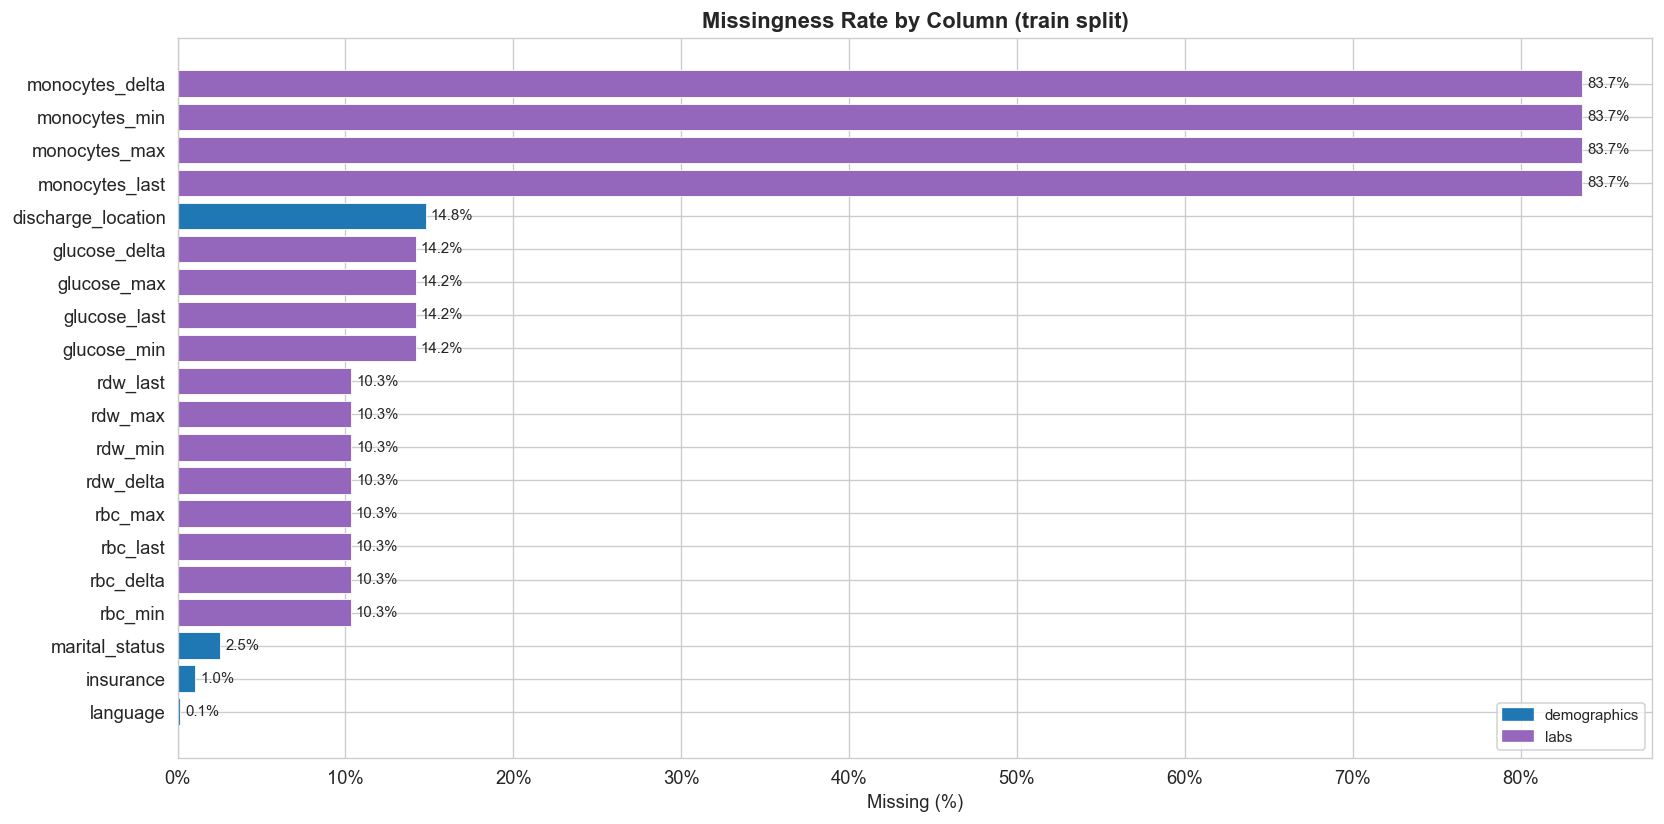

In [5]:
# --- 5. Bar chart: missingness by column, color-coded by family ---
plot_df = missing_feat[missing_feat["null_pct"] > 0].copy()

FAMILY_COLORS = {
    "demographics": "#1f77b4",
    "utilization":  "#ff7f0e",
    "codes":        "#2ca02c",
    "medications":  "#d62728",
    "labs":         "#9467bd",
    "target":       "#8c564b",
    "split":        "#7f7f7f",
}

colors = [FAMILY_COLORS.get(f, "#7f7f7f") for f in plot_df["family"]]

fig, ax = plt.subplots(figsize=(14, max(6, len(plot_df) * 0.35)))
bars = ax.barh(range(len(plot_df)), plot_df["null_pct"], color=colors, edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["column"])
ax.invert_yaxis()
ax.set_xlabel("Missing (%)")
ax.set_title("Missingness Rate by Column (train split)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

# Annotate bars with percentage
for i, (_, r) in enumerate(plot_df.iterrows()):
    ax.text(r["null_pct"] + 0.3, i, f"{r['null_pct']:.1f}%", va="center", fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=f) for f, c in FAMILY_COLORS.items() if f in plot_df["family"].unique()]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

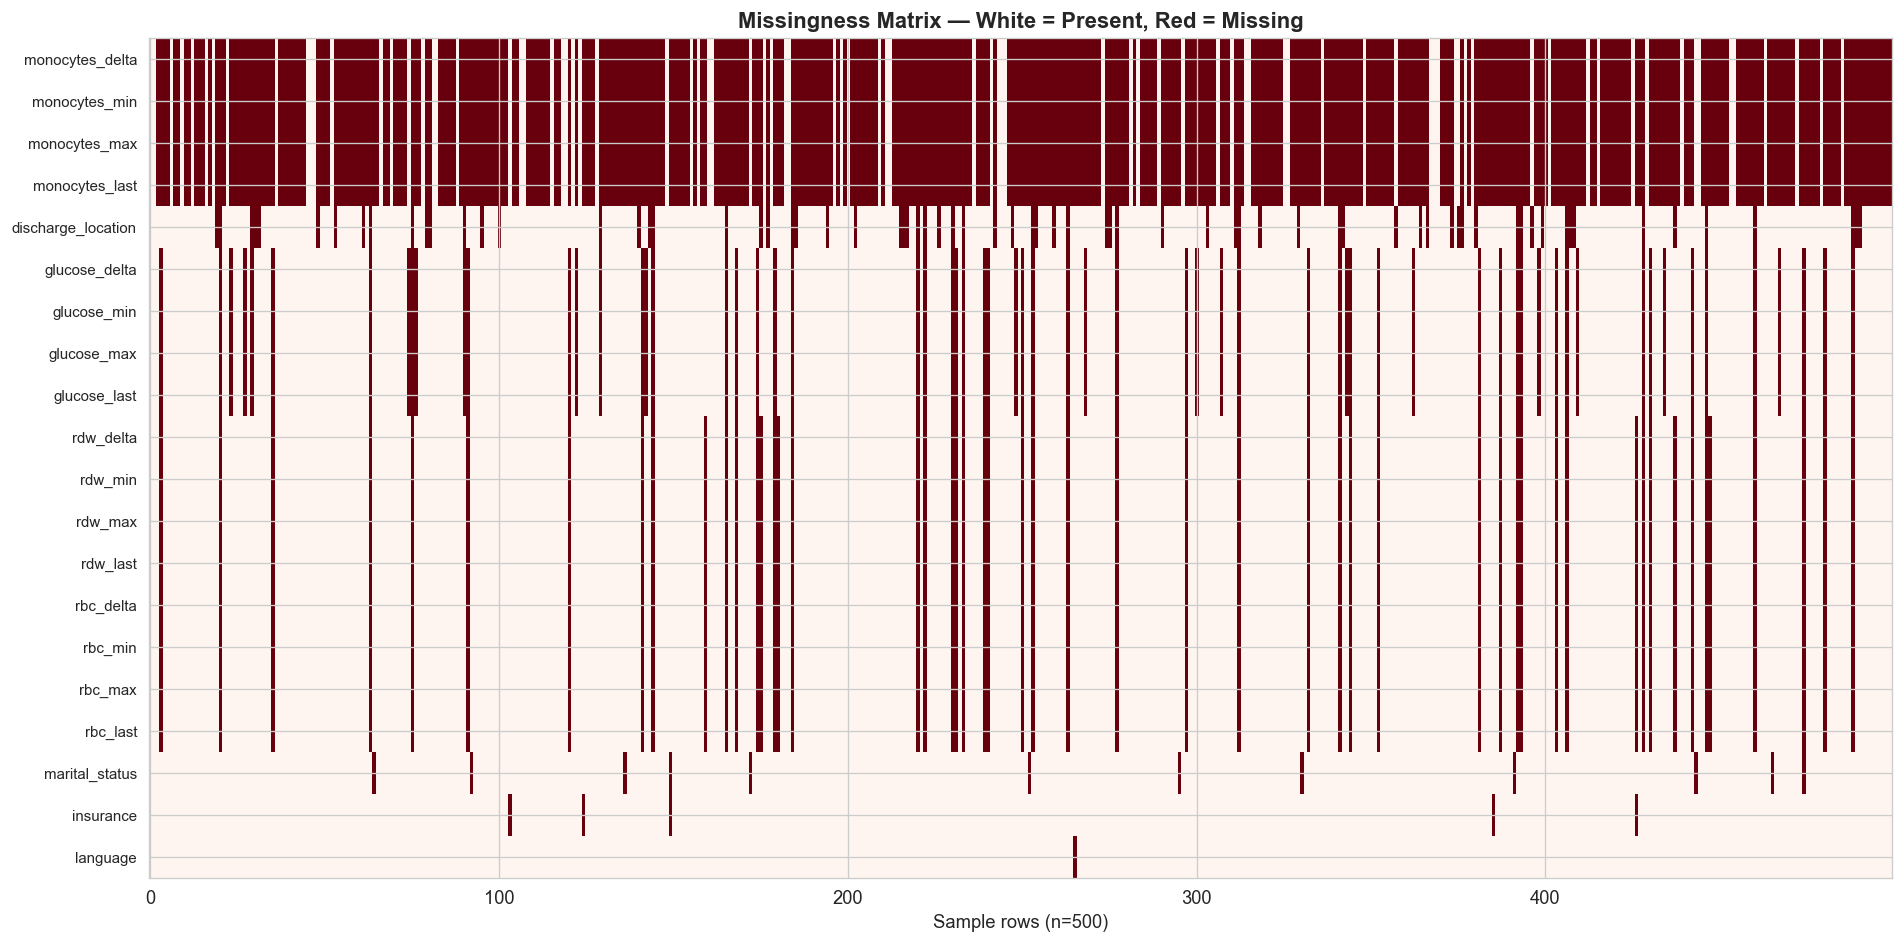

In [6]:
# --- 6. Missingness matrix: do nulls cluster together? ---
# Sample 500 rows for visual clarity; sort by columns with any missingness
cols_with_nulls = [c for c in FEATURE_COLS if df[c].isnull().any()]
if cols_with_nulls:
    sample = df[cols_with_nulls].sample(n=min(500, len(df)), random_state=42)
    # Sort by most-missing columns first
    null_order = sample.isnull().sum().sort_values(ascending=False).index.tolist()
    sample = sample[null_order]

    fig, ax = plt.subplots(figsize=(16, 8))
    # White = present, dark = missing
    ax.imshow(sample.isnull().T, aspect="auto", cmap="Reds", interpolation="none")
    ax.set_yticks(range(len(sample.columns)))
    ax.set_yticklabels(sample.columns, fontsize=9)
    ax.set_xlabel(f"Sample rows (n={len(sample)})")
    ax.set_title("Missingness Matrix — White = Present, Red = Missing", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in feature columns — your dataset is complete!")

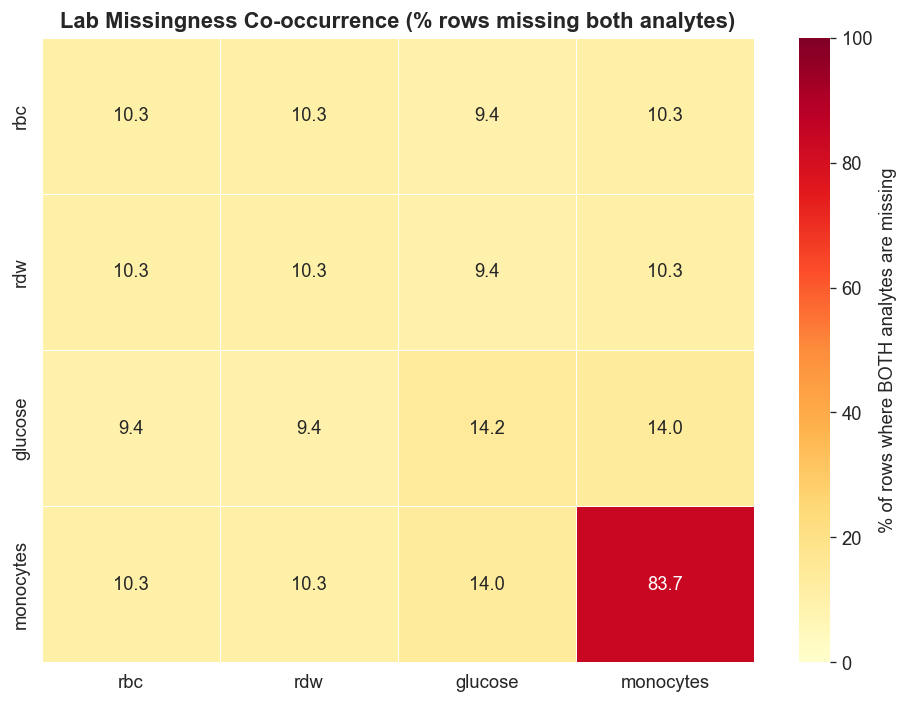


=== Per-analyte measurement rates ===
  rbc_measured             :  89.7% measured  ( 10.3% missing)
  rdw_measured             :  89.7% measured  ( 10.3% missing)
  glucose_measured         :  85.8% measured  ( 14.2% missing)
  monocytes_measured       :  16.3% measured  ( 83.7% missing)


In [7]:
# --- 7. Lab missingness co-occurrence ---
# Lab features often go missing together (a patient with no blood draw has nulls
# across all analytes). The co-occurrence matrix quantifies this.
lab_cols = FAMILIES["labs"]
lab_cols_present = [c for c in lab_cols if c in df.columns]

if lab_cols_present:
    # Extract the _measured flags only (these tell us if the analyte was drawn)
    measured_cols = [c for c in lab_cols_present if c.endswith("_measured")]
    if measured_cols:
        measured = df[measured_cols].copy()
        # Rename for readability: rbc_measured -> rbc
        measured.columns = [c.replace("_measured", "") for c in measured_cols]

        # Co-occurrence: for each pair, what fraction of rows lack both?
        n = len(measured)
        analytes = measured.columns.tolist()
        co_occurrence = pd.DataFrame(index=analytes, columns=analytes, dtype=float)
        for a in analytes:
            for b in analytes:
                co_occurrence.loc[a, b] = ((measured[a] == 0) & (measured[b] == 0)).sum() / n * 100

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(
            co_occurrence.astype(float),
            annot=True, fmt=".1f", cmap="YlOrRd",
            vmin=0, vmax=100, linewidths=0.5, ax=ax,
            cbar_kws={"label": "% of rows where BOTH analytes are missing"}
        )
        ax.set_title("Lab Missingness Co-occurrence (% rows missing both analytes)", fontweight="bold")
        plt.tight_layout()
        plt.show()

        # Individual measurement rates
        print("\n=== Per-analyte measurement rates ===")
        for c in measured_cols:
            pct_measured = df[c].mean() * 100
            print(f"  {c:<25s}: {pct_measured:5.1f}% measured  ({100-pct_measured:5.1f}% missing)")
    else:
        print("No _measured flag columns found in lab features.")
else:
    print("No lab columns found in the dataset.")

In [8]:
# --- 8. Threshold analysis ---
# Bucket features by missingness severity
def severity(pct):
    if pct == 0:
        return "✓ complete"
    elif pct <= 5:
        return "low (<5%)"
    elif pct <= 15:
        return "moderate (5–15%)"
    elif pct <= 50:
        return "high (15–50%)"
    else:
        return "severe (>50%)"

missing_feat["severity"] = missing_feat["null_pct"].apply(severity)

print("=== Missingness severity breakdown ===\n")
for sev in ["✓ complete", "low (<5%)", "moderate (5–15%)", "high (15–50%)", "severe (>50%)"]:
    subset = missing_feat[missing_feat["severity"] == sev]
    if len(subset):
        print(f"\n{sev} ({len(subset)} columns):")
        for _, r in subset.iterrows():
            print(f"  • {r['column']:<35s} {r['null_pct']:5.1f}%  [{r['family']}]")
    else:
        print(f"\n{sev}: (none)")

=== Missingness severity breakdown ===


✓ complete (22 columns):
  • rdw_measured                          0.0%  [labs]
  • glucose_measured                      0.0%  [labs]
  • rbc_measured                          0.0%  [labs]
  • monocytes_measured                    0.0%  [labs]
  • split_bucket                          0.0%  [split]
  • split_name                            0.0%  [split]
  • recent_ed_visits                      0.0%  [utilization]
  • age                                   0.0%  [demographics]
  • gender                                0.0%  [demographics]
  • race                                  0.0%  [demographics]
  • admission_type                        0.0%  [demographics]
  • prior_admission_count                 0.0%  [utilization]
  • prior_inpatient_days                  0.0%  [utilization]
  • index_los_days                        0.0%  [utilization]
  • on_insulin                            0.0%  [medications]
  • diagnosis_count                     

## 9. Missingness Mechanism Classification

Based on the patterns above, we classify each column's missingness into one of three mechanisms:

| Mechanism | Meaning | Example |
|---|---|---|
| **MCAR** (Missing Completely at Random) | Missingness is unrelated to any observed or unobserved variable. The missing values are a random subset. | A lab wasn't drawn because the phlebotomist was busy — unrelated to the patient's condition. |
| **MAR** (Missing at Random) | Missingness is related to *observed* variables but not the missing value itself. | Patients without insurance are more likely to have missing `discharge_location` — but we *know* their insurance status. |
| **MNAR** (Missing Not at Random) | Missingness is related to the *missing value itself*. | A patient with no prior admissions has `prior_inpatient_days = NULL` — the null *means* "no history." |

### Column-by-column assessment

- **Demographics** (`discharge_location`, `marital_status`): ~0–5% null. Likely **MAR** — administrative omissions correlated with admission type / insurance. Low enough for simple imputation.
- **Labs** (`rbc_*`, `rdw_*`, `glucose_*`, `monocytes_*`): 10–85% null. **MAR** — missingness is driven by whether the patient is in the ICU (observed via other features). Non-ICU patients rarely get these specific labs. The `_measured` flags are the imputation anchor.
- **Utilization** (`prior_*`, `recent_ed_visits`): These are COALESCE'd to 0 in the SQL pipeline, so missingness should be 0%. If any nulls appear, it's a data pipeline bug.
- **Medications** (`medication_count`, etc.): COALESCE'd to 0/false. Should be 0% null.
- **Codes** (`diagnosis_count`, `procedure_count`): COALESCE'd to 0. Should be 0% null.
- **Target** (`readmission_30d`): COALESCE'd to 0. Should be 0% null.

In [9]:
# --- 10. Missingness policy assignment ---
# Based on the mechanism classification, assign an imputation policy to each column.
# These policies will be applied in Phase F (sklearn ColumnTransformer, fit on train only).

POLICY_RULES = {
    # Demographics: low null %, categorical -> mode
    "discharge_location": "impute_mode",
    "marital_status":    "impute_mode",
    "language":          "impute_mode",
    "race":              "impute_mode",
    "insurance":         "impute_mode",
    
    # Labs: MAR, medium-to-high null %, numeric -> missing indicator + median
    # (rbc_last, rbc_max, rbc_min, rbc_delta, rbc_measured, etc.)
    # Pattern: all lab value columns get the indicator+median treatment
}

# Auto-assign policies
def assign_policy(col, null_pct, family, dtype):
    # Already complete — no policy needed
    if null_pct == 0:
        return "no_missing"
    
    # Lab values (MAR, % varies) — indicator + median
    if family == "labs":
        if col.endswith("_measured"):
            return "no_missing"  # _measured is 0/1 and never null
        return "missing_indicator+impute_median"
    
    # Demographics categorical (low %) — mode
    if family == "demographics":
        return "impute_mode"
    
    # Catch-all
    if null_pct <= 5:
        return "impute_median"
    elif null_pct <= 50:
        return "missing_indicator+impute_median"
    else:
        return "drop"

policy_table = missing_feat.copy()
policy_table["missingness_mechanism"] = "MCAR"  # default, overridden below
policy_table.loc[policy_table["family"] == "labs",     "missingness_mechanism"] = "MAR"
policy_table.loc[policy_table["family"] == "demographics", "missingness_mechanism"] = "MAR"
policy_table["policy"] = policy_table.apply(
    lambda r: assign_policy(r["column"], r["null_pct"], r["family"], None), axis=1
)

# Override specific columns based on clinical reasoning
# (these are documented in the markdown cell above)
OVERRIDES = {
    # Utilization: COALESCE'd to 0 in SQL — any null is a pipeline error, not a modeling concern
    "prior_admission_count": "no_missing",
    "prior_inpatient_days":  "no_missing",
    "recent_ed_visits":      "no_missing",
    "index_los_days":        "no_missing",
    # Codes: COALESCE'd to 0
    "diagnosis_count": "no_missing",
    "procedure_count": "no_missing",
    "has_procedure":   "no_missing",
    # Medications: COALESCE'd to 0/false
    "medication_count":       "no_missing",
    "medication_order_count": "no_missing",
    "on_anticoagulant":       "no_missing",
    "on_insulin":             "no_missing",
    # Target: COALESCE'd to 0
    "readmission_30d": "no_missing",
    # Demographics with 0% null
    "age":              "no_missing",
    "gender":           "no_missing",
    "admission_type":   "no_missing",
    "split_bucket":     "no_missing",
    "split_name":       "no_missing",
}
for col, pol in OVERRIDES.items():
    if col in policy_table["column"].values:
        policy_table.loc[policy_table["column"] == col, "policy"] = pol

# Display final policy summary
policy_summary = (
    policy_table[["column", "family", "null_pct", "missingness_mechanism", "policy"]]
    .sort_values(["family", "null_pct"], ascending=[True, False])
)
print("=== Missingness Policy Table ===\n")
for _, r in policy_summary.iterrows():
    flag = "⚠️ " if r["null_pct"] > 0 else "✓  "
    print(f"{flag}{r['column']:<35s} {r['family']:<15s} {r['null_pct']:5.1f}%  {r['missingness_mechanism']:<6s}  → {r['policy']}")

# Count by policy
print("\n=== Policy distribution ===")
print(policy_summary["policy"].value_counts().to_string())

=== Missingness Policy Table ===

✓  diagnosis_count                     codes             0.0%  MCAR    → no_missing
✓  procedure_count                     codes             0.0%  MCAR    → no_missing
✓  has_procedure                       codes             0.0%  MCAR    → no_missing
⚠️ discharge_location                  demographics     14.8%  MAR     → impute_mode
⚠️ marital_status                      demographics      2.5%  MAR     → impute_mode
⚠️ insurance                           demographics      1.0%  MAR     → impute_mode
⚠️ language                            demographics      0.1%  MAR     → impute_mode
✓  age                                 demographics      0.0%  MAR     → no_missing
✓  gender                              demographics      0.0%  MAR     → no_missing
✓  race                                demographics      0.0%  MAR     → no_missing
✓  admission_type                      demographics      0.0%  MAR     → no_missing
⚠️ monocytes_delta                    

In [10]:
# --- 11. Export policy table ---
import os
from datetime import datetime, timezone

ARTIFACTS_DIR = "../artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
csv_path = f"{ARTIFACTS_DIR}/missingness_policy_{ts}.csv"
latest_path = f"{ARTIFACTS_DIR}/missingness_policy.csv"

export_cols = ["column", "family", "null_pct", "missingness_mechanism", "policy"]
policy_summary[export_cols].to_csv(csv_path, index=False)
policy_summary[export_cols].to_csv(latest_path, index=False)

print(f"✓ Policy table exported:")
print(f"  {csv_path}")
print(f"  {latest_path}  (latest symlink)")

# Also print a compact summary for the runbook
print("\n=== Copy-paste summary for runbook ===\n")
print("| Column | Family | Null % | Mechanism | Policy |")
print("|--------|--------|--------|-----------|--------|")
for _, r in policy_summary[policy_summary["null_pct"] > 0].iterrows():
    print(f"| {r['column']} | {r['family']} | {r['null_pct']:.1f}% | {r['missingness_mechanism']} | {r['policy']} |")

✓ Policy table exported:
  ../artifacts/missingness_policy_20260612T123625Z.csv
  ../artifacts/missingness_policy.csv  (latest symlink)

=== Copy-paste summary for runbook ===

| Column | Family | Null % | Mechanism | Policy |
|--------|--------|--------|-----------|--------|
| discharge_location | demographics | 14.8% | MAR | impute_mode |
| marital_status | demographics | 2.5% | MAR | impute_mode |
| insurance | demographics | 1.0% | MAR | impute_mode |
| language | demographics | 0.1% | MAR | impute_mode |
| monocytes_delta | labs | 83.7% | MAR | missing_indicator+impute_median |
| monocytes_min | labs | 83.7% | MAR | missing_indicator+impute_median |
| monocytes_max | labs | 83.7% | MAR | missing_indicator+impute_median |
| monocytes_last | labs | 83.7% | MAR | missing_indicator+impute_median |
| glucose_delta | labs | 14.2% | MAR | missing_indicator+impute_median |
| glucose_max | labs | 14.2% | MAR | missing_indicator+impute_median |
| glucose_last | labs | 14.2% | MAR | missing_

## 12. Summary & Next Steps

### Findings

The missingness analysis above tells us:

1. **Which columns have nulls, and how many.** The bar chart and threshold table quantify the problem.
2. **Whether nulls cluster.** The matrix plot shows if missingness is random or systematic (e.g., entire rows missing all labs = patient didn't get a blood draw).
3. **Lab co-occurrence.** If `rbc_measured == 0`, does `rdw_measured` also tend to be 0? This informs whether a single "had any labs" flag is sufficient or per-analyte flags are needed.
4. **Mechanism (MCAR / MAR / MNAR).** This determines whether simple imputation is valid or a more careful approach is required.

### Policies assigned

| Policy | When to use | Applied to |
|---|---|---|
| `no_missing` | Column is complete (0% null) or COALESCE'd in SQL | demographics (age/gender/etc.), utilization, codes, medications, target |
| `impute_mode` | Categorical with low null % (<5%) | discharge_location, marital_status, language, race, insurance |
| `missing_indicator+impute_median` | Numeric with MAR missingness (labs not drawn) | All lab value columns (rbc_*, rdw_*, glucose_*, monocytes_*) |
| `drop` | >50% null and no clear MAR anchor | (none expected in current pipeline) |

### What's next

1. **Run this notebook** to confirm the actual null % values from BigQuery.
2. **Review the policy table** — adjust any policies based on clinical judgment.
3. **Phase F (imputation pipeline):** Implement a `sklearn.compose.ColumnTransformer` that applies the policies above, fit on train only, transform on val/test.
4. **Feature selection notebook:** With missingness handled, proceed to the five selection methods specified in `workflow.md §5`.